In [2]:
import akshare as ak
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import re
import math

# 指定支持中文的字体，例如SimHei或者Microsoft YaHei
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

figsize = (15, 5)

# 房地产投资分析

## 1 房地产开发投资的构成

房地产开发投资包括：建筑工程投资、安装工程投资、设备工器具购置投资和其他费用投资

建筑工程投资和其他费用投资占比最大

In [1]:
df_real_estate_development_capital_monthly = ak.macro_china_nbs_nation(
    kind="月度数据", path="房地产>房地产开发投资情况", period="2002-"
)

NameError: name 'ak' is not defined

In [ ]:
# 房地产施工面积
df_real_estate_floor_area_monthly = ak.macro_china_nbs_nation(
    kind="月度数据", path="房地产>房地产施工、竣工面积", period="2002-"
)

In [ ]:
# df_real_estate_capital_structure_monthly = ak.macro_china_nbs_nation(
#     kind="月度数据", path="房地产>房地产开发投资实际到位资金", period="2002-"
# )

In [ ]:
df_real_estate_capital_structure_yearly = ak.macro_china_nbs_nation(
    kind="年度数据", path="固定资产投资和房地产>房地产开发企业资金来源", period="2002-"
)

In [ ]:
df_real_estate_sales_area_monthly = ak.macro_china_nbs_nation(
    kind="月度数据", path="房地产>商品住宅销售面积", period="2002-"
)

In [ ]:
df_bond_china_yield = ak.bond_zh_us_rate(start_date="20020101")

In [ ]:
df_bond_china_yield.set_index("日期", inplace=True)

In [ ]:
df_real_estate_development_capital_monthly = (
    df_real_estate_development_capital_monthly.transpose().iloc[::-1]
)
df_real_estate_floor_area_monthly = df_real_estate_floor_area_monthly.transpose().iloc[
    ::-1
]
# df_real_estate_capital_structure_monthly = (
#     df_real_estate_capital_structure_monthly.transpose().iloc[::-1]
# )
df_real_estate_capital_structure_yearly = (
    df_real_estate_capital_structure_yearly.transpose().iloc[::-1]
)
df_real_estate_sales_area_monthly = df_real_estate_sales_area_monthly.transpose().iloc[
    ::-1
]

房地产开发建筑工程投资与房地产施工面积、钢价走势接近

建筑工程投资与宏观经济关联度较高

<Axes: >

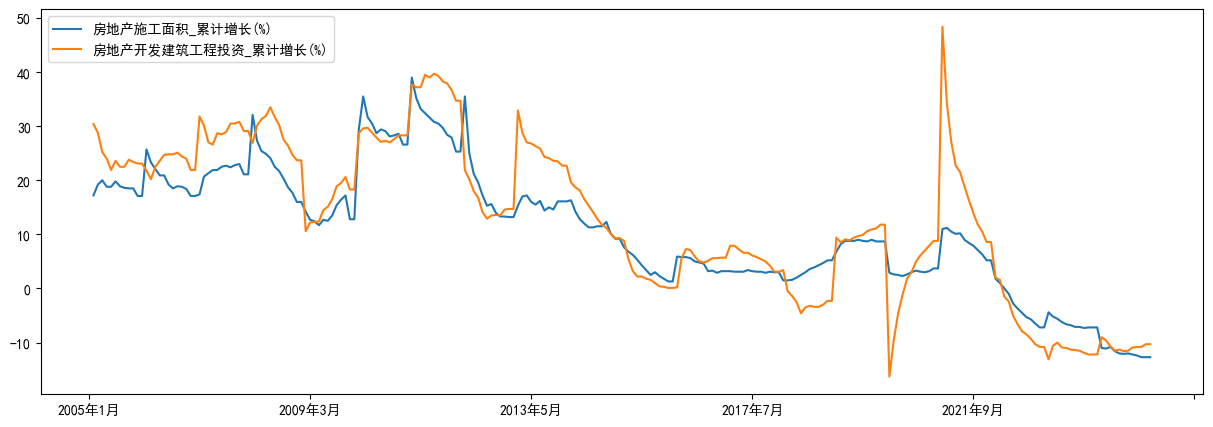

In [ ]:
pd.DataFrame(
    {
        "房地产施工面积_累计增长(%)": df_real_estate_floor_area_monthly[
            "房地产施工面积_累计增长(%)"
        ],
        "房地产开发建筑工程投资_累计增长(%)": df_real_estate_development_capital_monthly[
            "房地产开发建筑工程投资_累计增长(%)"
        ],
    }
).loc["2005年1月":].ffill().plot(figsize=figsize)

安装工程投资与房地产竣工面积走势接近

<Axes: >

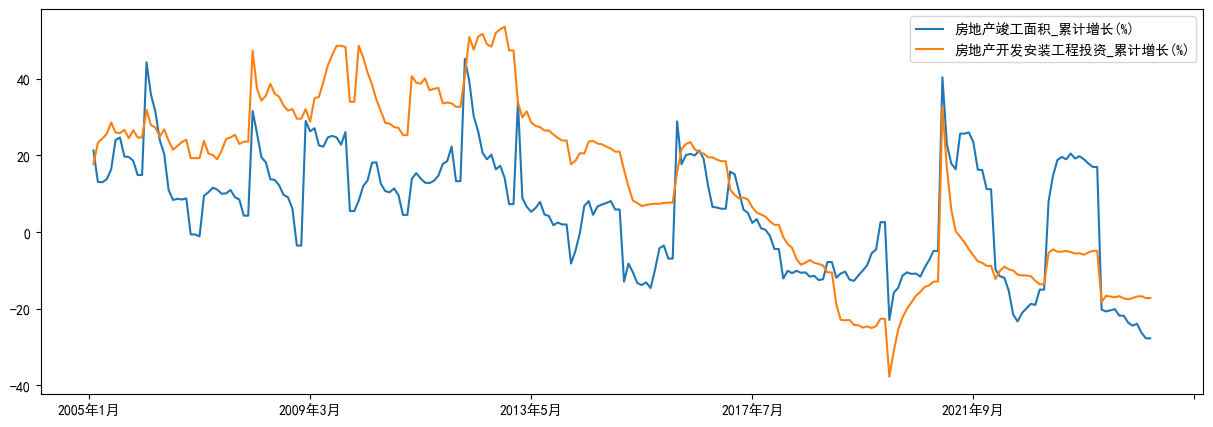

In [ ]:
pd.DataFrame(
    {
        "房地产竣工面积_累计增长(%)": df_real_estate_floor_area_monthly[
            "房地产竣工面积_累计增长(%)"
        ],
        "房地产开发安装工程投资_累计增长(%)": df_real_estate_development_capital_monthly[
            "房地产开发安装工程投资_累计增长(%)"
        ],
    }
).loc["2005年1月":].ffill().plot(figsize=figsize)

其他费用中土地购置费占比最大，走势也接近

土地购置是一个滞后指标，反映过去一年土地供给面积和土地价格

土地购置是房地产开发投资最大的干扰项（滞后但占比大）

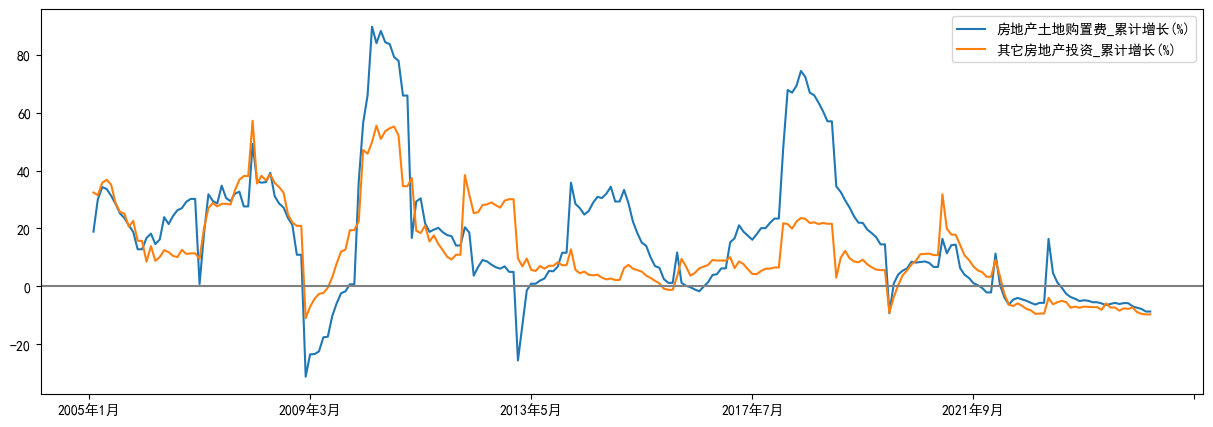

In [ ]:
pd.DataFrame(
    {
        "房地产土地购置费_累计增长(%)": df_real_estate_development_capital_monthly[
            "房地产土地购置费_累计增长(%)"
        ],
        "其它房地产投资_累计增长(%)": df_real_estate_development_capital_monthly[
            "其它房地产投资_累计增长(%)"
        ],
    }
).loc["2005年1月":].ffill().plot(figsize=figsize)

plt.axhline(y=0, c="gray")

## 2 房地产开发资金来源

房地产开发资金来源包括：
- 国内贷款
- 自筹资金
- 其他资金
- 利用外资
- 应付款

In [ ]:
# 2017年开始统计局没有公布其他资金的总数，但是公布了分项数据。这里手动加总。
df_real_estate_capital_structure_yearly["房地产开发企业其他资金来源(亿元)"].loc[
    "2017年":
] = (
    df_real_estate_capital_structure_yearly[
        [
            "房地产开发企业定金及预收款(亿元)",
            "房地产开发企业个人按揭贷款(亿元)",
            "房地产开发企业其他到位资金(亿元)",
        ]
    ]
    .sum(axis=1)
    .loc["2017年":]
)

/tmp/ipykernel_15206/645120308.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_real_estate_capital_structure_yearly["房地产开发企业其他资金来源(亿元)"].loc[


<Axes: >

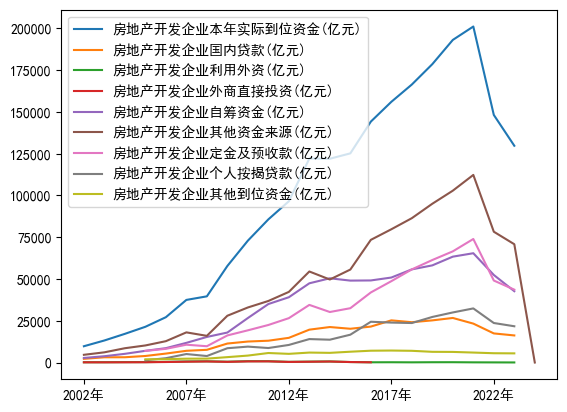

In [ ]:
df_real_estate_capital_structure_yearly.plot()

### 2.1 国内贷款

国内贷款包括银行贷款和非银贷款（非标融资）

非标融资数据与真实情况有出入：房企通过贷款拿地有严格的监管限制，所以非标融资以【明股实债】的方式记入自筹资金项目

### 2.2 自筹资金

房企自有资金
房企自己筹集、借入的资金（信用债、资产证券化）
股票市场IPO、定增融资
未分配利润

### 2.3 其他资金

定金及预收款（大头）
个人按揭贷款（大头）
其他到位资金

房企实行高周转策略

高周转意味着房企高度依赖房地产销售，导致其他资金占房地产资金来源的比重越来越大

### 2.4 应付款

房地产供应链abs：把房企供应商的应收账款打包成资产支持专项计划，到期后房企向专项计划付款。

帮助房企隐藏有息负债，逃避监管

## 3 从房地产销售到房地产开发投资

房地产开发投资增速与房地产销售增速正相关：

房地产销售改善 - 房企库存下降 - 房企预期未来房价会上涨 - 房企拿地、补库存 - 新开工、房地产开发投资、房地产施工、竣工都会提升

2016年以后这种关系在减弱

### 如何判断房地产销售

房地产供给是相对刚性的，由政府控制（土地红线）

需求端：
1. 政策刺激：限售、限贷、落户
2. 货币刺激：
  - 流动性：M2与名义GDP的差值
  - 国债利率：无风险利率太低，全社会有避险需求的资金就会寻找替代无风险资产的其他资产（这类资产有一个特点：供给稀缺），房地产（尤其是一线城市）景气度就会提升



/tmp/ipykernel_15206/767080596.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


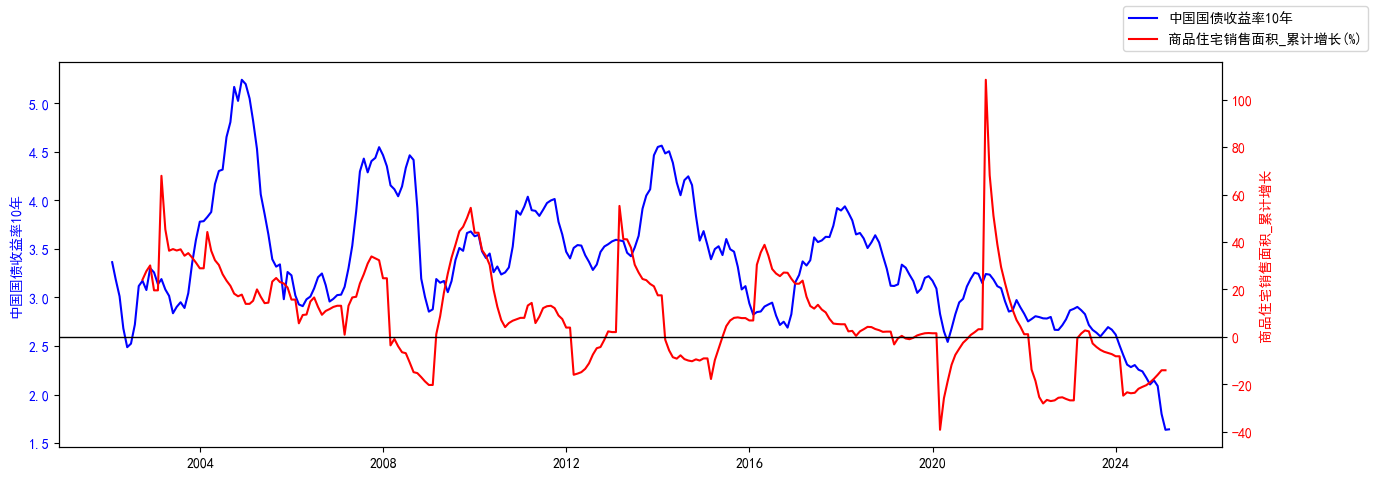

In [ ]:
df1 = (
    df_bond_china_yield.set_index(
        pd.to_datetime(df_bond_china_yield.index, format="%Y-%m-%d")
    )
    .resample("M")
    .mean()
)
df2 = df_real_estate_sales_area_monthly.set_index(
    pd.to_datetime(df_real_estate_sales_area_monthly.index, format="%Y年%m月")
    + pd.offsets.MonthEnd(0)
)

fig, ax1 = plt.subplots(figsize=figsize)

ax1.plot(df1.index, df1["中国国债收益率10年"], label="中国国债收益率10年", c="blue")
ax1.set_ylabel("中国国债收益率10年", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()

ax2.plot(
    df2.index,
    df2["商品住宅销售面积_累计增长(%)"].ffill(),
    label="商品住宅销售面积_累计增长(%)",
    c="red",
)
ax2.set_ylabel("商品住宅销售面积_累计增长", color="red")
ax2.tick_params(axis="y", labelcolor="red")

fig.legend()
plt.axhline(y=0, c="black", linewidth=1)

## 3 房地产开发投资的预测和测算

![房地产投资分析](./imgs/房地产投资分析_1.png)

### 3.1 土地购置

使用规律（100个城市的土地成交价款领先土地购置费12个月）拟合未来的土地购置费

### 3.2 建安投资

建安投资 = 施工面积 * 单位面积施工投资金额

单位面积施工投资金额中建安成本占比最高：60%-70%

#### 数据来源

建设工程造价信息网：
https://www.cecn.org.cn/

武汉住宅建安成本
https://www.cecn.org.cn/Sand/api/CECNCom/GetReportGetTimeData?sign=f66c39a587b5406a391fdf1740366887&SubsArea=42&NeedCount=50

住宅建安成本
https://www.cecn.org.cn/Sand/api/CECNCom/GetReportGetTimeData?sign=f66c39a587b5406a391fdf1740366887&NeedCount=50

In [9]:
# 住宅建安成本
df_construction_installation_cost = pd.DataFrame(
    {
        "多层": [
            979.0,
            979.0,
            1015.0,
            1053.0,
            1096.0,
            1177.0,
            1233.0,
            1256.0,
            1284.0,
            1281.0,
            1339.0,
            1350.0,
            1362.0,
            1354.0,
            1369.0,
            1331.0,
            1431.0,
            1499.0,
            1568.0,
            1638.0,
            1649.0,
            1712.0,
            1696.0,
            1752.0,
            1772.0,
            1857.0,
            1908.0,
            1839.0,
            1888.0,
            1850.0,
            1828.0,
        ],
        "小高层": [
            1319.0,
            1292.0,
            1338.0,
            1377.0,
            1411.0,
            1461.0,
            1520.0,
            1576.0,
            1570.0,
            1591.0,
            1639.0,
            1637.0,
            1654.0,
            1629.0,
            1599.0,
            1571.0,
            1659.0,
            1748.0,
            1826.0,
            1891.0,
            1881.0,
            1948.0,
            1971.0,
            1997.0,
            2027.0,
            2120.0,
            2164.0,
            2200.0,
            2189.0,
            2137.0,
            2136.0,
        ],
        "高层": [
            1513.0,
            1494.0,
            1537.0,
            1547.0,
            1595.0,
            1633.0,
            1700.0,
            1730.0,
            1774.0,
            1811.0,
            1835.0,
            1839.0,
            1817.0,
            1791.0,
            1758.0,
            1783.0,
            1816.0,
            1937.0,
            2017.0,
            2068.0,
            2120.0,
            2194.0,
            2230.0,
            2261.0,
            2301.0,
            2426.0,
            2451.0,
            2498.0,
            2479.0,
            2487.0,
            2484.0,
        ],
    },
    index=[
        "08年下",
        "09年上",
        "09年下",
        "10年上",
        "10年下",
        "11年上",
        "11年下",
        "12年上",
        "12年下",
        "13年上",
        "13年下",
        "14年上",
        "14年下",
        "15年上",
        "15年下",
        "16年上",
        "16年下",
        "17年上",
        "17年下",
        "18年上",
        "18年下",
        "19年上",
        "19年下",
        "20年上",
        "20年下",
        "21年上",
        "21年下",
        "22年上",
        "22年下",
        "23年上",
        "23年下",
    ],
)

<Axes: >

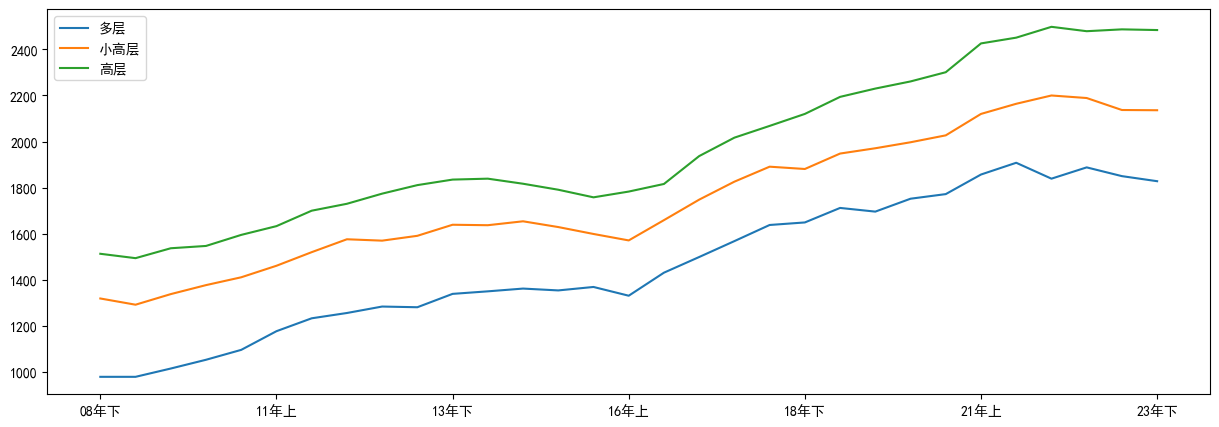

In [10]:
df_construction_installation_cost.plot(figsize=figsize)